# Machine Learning - Assignment 2

## Decision tree induction algorithm for classification tasks

The aim of the assignment is to:

* Implement a decision tree induction algorithm for classification tasks.
* Make sure it works for real valued features and nominal features (categorical features without rank, e.g., red - blue - green).
* Test the algorithm on 3 datasets.

Follow the instructions and implement what is missing to complete the assignment.

## Assignment preparations

Import the necessary libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Decision tree model

The main objective is to implement the decision tree model. The implemented decision tree needs to be recursive model.

### 1) Grow Tree

This function creates the decision tree recursively.

In [ ]:
def grow_tree(data, feature_types, current_depth=0, max_depth=10, min_samples_split=2, min_purity=0.95):

    X = data[:, :-1]  # Features
    y = data[:, -1]   # Target

    # Stopping condition 1: Pure node (only one class)
    if check_purity(y):
        return create_leaf(y)

    # Stopping condition 2: Max depth reached
    if current_depth >= max_depth:
        return create_leaf(y)

    # Stopping condition 3: Not enough samples to split
    if len(data) < min_samples_split:
        return create_leaf(y)

    # Stopping condition 4: Node is very pure (almost all same class)
    if check_min_purity(y, min_purity):
        return create_leaf(y)

    # Find the best feature to split on
    best_split_feature, best_split_value = find_best_split(data, feature_types)

    # If no good split found
    if best_split_feature is None:
        return create_leaf(y)

    # Split the data
    data_left, data_right = split_data(data, best_split_feature, best_split_value, feature_types)

    # If split results in empty node
    if len(data_left) == 0 or len(data_right) == 0:
        return create_leaf(y)

    # Create decision node
    node = {}
    node['feature_index'] = best_split_feature
    node['split_value'] = best_split_value
    node['feature_type'] = feature_types[best_split_feature]

    # Recursively grow left and right subtrees
    node['left'] = grow_tree(data_left, feature_types, current_depth + 1, max_depth, min_samples_split, min_purity)
    node['right'] = grow_tree(data_right, feature_types, current_depth + 1, max_depth, min_samples_split, min_purity)

    return node

### 2) Growth stopping conditions

Functions to determine when to stop growing the tree.

In [ ]:
def check_purity(y):

    return len(np.unique(y)) == 1

def check_min_purity(y, min_purity):
    unique, counts = np.unique(y, return_counts=True)
    purity = np.max(counts) / len(y)
    return purity >= min_purity

def create_leaf(y):
    unique, counts = np.unique(y, return_counts=True)
    return {'leaf': True, 'class': unique[np.argmax(counts)]}

### 3) Best feature for splitting nodes

Using Gini Impurity to find the best feature to split on.

In [ ]:
def calculate_gini_impurity(y):

    if len(y) == 0:
        return 0

    unique, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    gini = 1 - np.sum(probabilities ** 2)
    return gini

def calculate_information_gain(y_parent, y_left, y_right):
    n_parent = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)

    if n_left == 0 or n_right == 0:
        return 0

    gini_parent = calculate_gini_impurity(y_parent)
    gini_left = calculate_gini_impurity(y_left)
    gini_right = calculate_gini_impurity(y_right)

    weighted_gini = (n_left / n_parent) * gini_left + (n_right / n_parent) * gini_right
    information_gain = gini_parent - weighted_gini

    return information_gain

def find_best_split(data, feature_types):
    X = data[:, :-1]
    y = data[:, -1]

    best_gain = -1
    best_feature = None
    best_value = None

    # Try each feature
    for feature_idx in range(X.shape[1]):
        feature_values = X[:, feature_idx]
        feature_type = feature_types[feature_idx]

        if feature_type == 'r':  # Real-valued feature
            # Use mean as split threshold
            split_value = np.mean(feature_values)

            # Split data
            left_mask = feature_values < split_value
            right_mask = ~left_mask

            y_left = y[left_mask]
            y_right = y[right_mask]

            # Calculate information gain
            gain = calculate_information_gain(y, y_left, y_right)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_value = split_value

        else:  # Nominal feature
            # Try each unique value as a split
            unique_values = np.unique(feature_values)

            for value in unique_values:
                left_mask = feature_values == value
                right_mask = ~left_mask

                y_left = y[left_mask]
                y_right = y[right_mask]

                # Calculate information gain
                gain = calculate_information_gain(y, y_left, y_right)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_value = value

    return best_feature, best_value

### 4) Split data

Split data based on a feature and value.

In [ ]:
def split_data(data, feature_index, split_value, feature_types):

    X = data[:, :-1]
    feature_type = feature_types[feature_index]

    if feature_type == 'r':  # Real-valued
        left_mask = X[:, feature_index] < split_value
    else:  # Nominal
        left_mask = X[:, feature_index] == split_value

    right_mask = ~left_mask

    data_left = data[left_mask]
    data_right = data[right_mask]

    return data_left, data_right

### 5) Predict with tree model

Traverse the tree to make predictions.

In [ ]:
def predict_sample(tree, sample, feature_types):

    # If leaf node, return the class
    if tree.get('leaf', False):
        return tree['class']

    # Get feature value for this sample
    feature_idx = tree['feature_index']
    split_value = tree['split_value']
    feature_type = tree['feature_type']
    sample_value = sample[feature_idx]

    # Decide which branch to follow
    if feature_type == 'r':  # Real-valued
        if sample_value < split_value:
            return predict_sample(tree['left'], sample, feature_types)
        else:
            return predict_sample(tree['right'], sample, feature_types)
    else:  # Nominal
        if sample_value == split_value:
            return predict_sample(tree['left'], sample, feature_types)
        else:
            return predict_sample(tree['right'], sample, feature_types)

def predict_with_tree(tree, X, feature_types):

    predictions = []
    for sample in X:
        pred = predict_sample(tree, sample, feature_types)
        predictions.append(pred)
    return np.array(predictions)

## Test decision tree model and compare with scikit learn

Test on 3 datasets and compare with scikit-learn implementation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing


### 6) Dataset 1: Wine

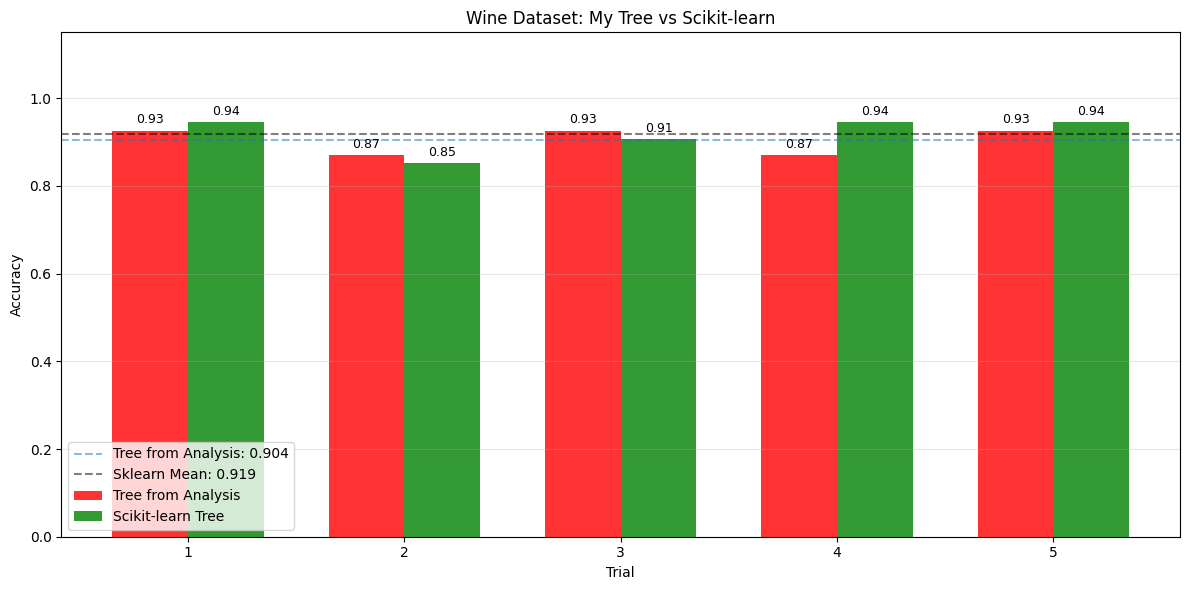

Wine Dataset Results:
Tree from Analysis - Mean Accuracy: 0.904 ± 0.027
Sklearn Tree - Mean Accuracy: 0.919 ± 0.036


In [ ]:


# Load wine dataset
data_wine = pd.read_csv("wine.csv")

# Convert all columns to numeric, handling any errors
for col in data_wine.columns:
    data_wine[col] = pd.to_numeric(data_wine[col], errors='coerce')

# Drop any rows with NaN values that might have resulted from conversion
data_wine = data_wine.dropna()

# Convert to numpy
data_wine = data_wine.to_numpy()

# All features are real-valued for wine dataset
feature_types_wine = ['r'] * (data_wine.shape[1] - 1)

# Run multiple trials
n_trials = 5
my_tree_scores = []
sklearn_scores = []

for trial in range(n_trials):
    # Shuffle and split data
    np.random.shuffle(data_wine)

    X = data_wine[:, :-1].astype(float)  # Ensure float type
    y = data_wine[:, -1].astype(float)   # Ensure float type

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=trial)

    # Prepare data for my tree (needs combined X and y)
    train_data = np.column_stack([X_train, y_train])

    # Train my tree
    my_tree = grow_tree(train_data, feature_types_wine, max_depth=10, min_samples_split=2)

    # Predict with my tree
    y_pred_my = predict_with_tree(my_tree, X_test, feature_types_wine)
    my_accuracy = accuracy_score(y_test, y_pred_my)
    my_tree_scores.append(my_accuracy)

    # Train and predict with sklearn
    sklearn_tree = DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=trial)
    sklearn_tree.fit(X_train, y_train)
    y_pred_sklearn = sklearn_tree.predict(X_test)
    sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
    sklearn_scores.append(sklearn_accuracy)

# Plot results
plt.figure(figsize=(12, 6))

x_pos = np.arange(n_trials)
width = 0.35

bars_my = plt.bar(
    x_pos - width/2,
    my_tree_scores,
    width,
    label='Tree from Analysis',
    color="red",
    alpha=0.8
)

bars_sklearn = plt.bar(
    x_pos + width/2,
    sklearn_scores,
    width,
    label='Scikit-learn Tree',
    color="green",
    alpha=0.8
)

plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Wine Dataset: My Tree vs Scikit-learn')
plt.xticks(x_pos, [f'{i+1}' for i in range(n_trials)])
plt.ylim(0, 1.15)   # 🔹 important: extra headroom
plt.grid(axis='y', alpha=0.3)

# 🔹 ADD VALUES ON BARS (this is the key fix)
plt.bar_label(bars_my, fmt='%.2f', padding=3, fontsize=9)
plt.bar_label(bars_sklearn, fmt='%.2f', padding=3, fontsize=9)

# Mean accuracy lines
plt.axhline(
    y=np.mean(my_tree_scores),
    linestyle='--',
    alpha=0.5,
    label=f'Tree from Analysis: {np.mean(my_tree_scores):.3f}'
)
plt.axhline(
    y=np.mean(sklearn_scores),
    linestyle='--',
    alpha=0.5,
    color="black",
    label=f'Sklearn Mean: {np.mean(sklearn_scores):.3f}'
)

plt.legend()
plt.tight_layout()
plt.show()

print(f"Wine Dataset Results:")
print(f"Tree from Analysis - Mean Accuracy: {np.mean(my_tree_scores):.3f} ± {np.std(my_tree_scores):.3f}")
print(f"Sklearn Tree - Mean Accuracy: {np.mean(sklearn_scores):.3f} ± {np.std(sklearn_scores):.3f}")

### 7) Dataset 2: Heart Disease

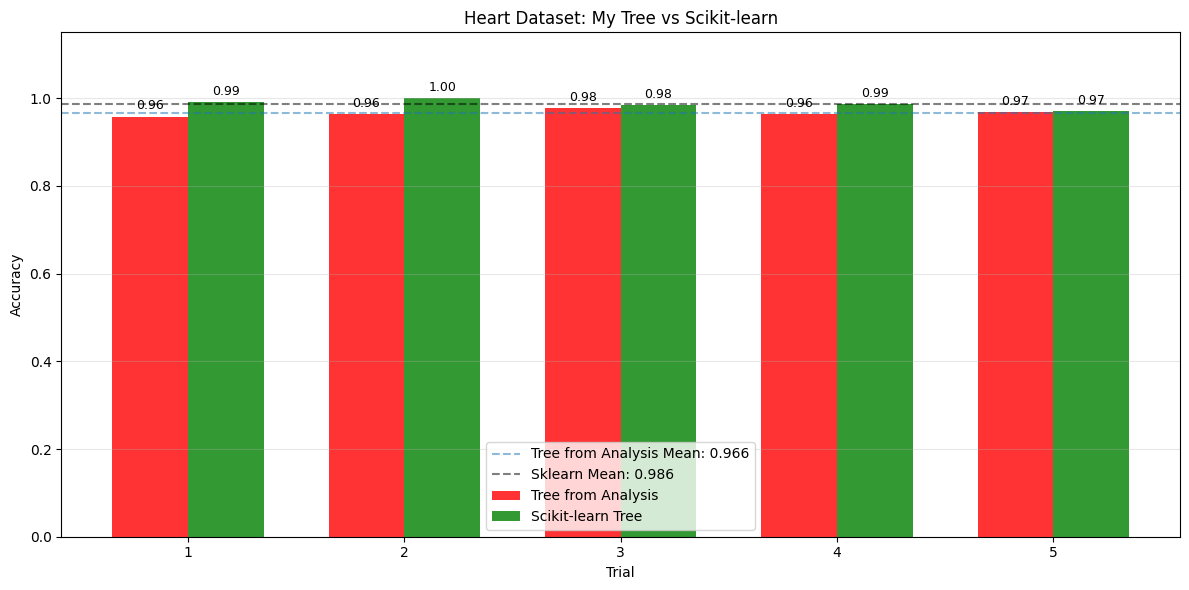

Heart Dataset Results:
Tree from Analysis - Mean Accuracy: 0.966 ± 0.006
Sklearn Tree - Mean Accuracy: 0.986 ± 0.009


In [ ]:
# Load heart dataset
data_heart = pd.read_csv("heart.csv")

# Convert all columns to numeric, handling any errors
for col in data_heart.columns:
    data_heart[col] = pd.to_numeric(data_heart[col], errors='coerce')

# Drop any rows with NaN values
data_heart = data_heart.dropna()

# Convert to numpy
data_heart = data_heart.to_numpy()

# Assume all features are real-valued (same assumption as wine)
feature_types_heart = ['r'] * (data_heart.shape[1] - 1)

# Run multiple trials
n_trials = 5
my_tree_scores = []
sklearn_scores = []

for trial in range(n_trials):
    # Shuffle and split data
    np.random.shuffle(data_heart)

    X = data_heart[:, :-1].astype(float)
    y = data_heart[:, -1].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=trial
    )

    # Prepare data for my tree
    train_data = np.column_stack([X_train, y_train])

    # Train my tree
    my_tree = grow_tree(
        train_data,
        feature_types_heart,
        max_depth=10,
        min_samples_split=2
    )

    # Predict with my tree
    y_pred_my = predict_with_tree(my_tree, X_test, feature_types_heart)
    my_accuracy = accuracy_score(y_test, y_pred_my)
    my_tree_scores.append(my_accuracy)

    # Train and predict with sklearn
    sklearn_tree = DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=2,
        random_state=trial
    )
    sklearn_tree.fit(X_train, y_train)
    y_pred_sklearn = sklearn_tree.predict(X_test)
    sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
    sklearn_scores.append(sklearn_accuracy)

# Plot results
plt.figure(figsize=(12, 6))

x_pos = np.arange(n_trials)
width = 0.35

bars_my = plt.bar(
    x_pos - width/2,
    my_tree_scores,
    width,
    label='Tree from Analysis',
    color="red",
    alpha=0.8
)

bars_sklearn = plt.bar(
    x_pos + width/2,
    sklearn_scores,
    width,
    label='Scikit-learn Tree',
    color="green",
    alpha=0.8
)

plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Heart Dataset: My Tree vs Scikit-learn')
plt.xticks(x_pos, [f'{i+1}' for i in range(n_trials)])
plt.ylim(0, 1.15)
plt.grid(axis='y', alpha=0.3)

# Add values on bars
plt.bar_label(bars_my, fmt='%.2f', padding=3, fontsize=9)
plt.bar_label(bars_sklearn, fmt='%.2f', padding=3, fontsize=9)

# Mean accuracy lines
plt.axhline(
    y=np.mean(my_tree_scores),
    linestyle='--',
    alpha=0.5,
    label=f'Tree from Analysis Mean: {np.mean(my_tree_scores):.3f}'
)
plt.axhline(
    y=np.mean(sklearn_scores),
    linestyle='--',
    alpha=0.5,
    color="black",
    label=f'Sklearn Mean: {np.mean(sklearn_scores):.3f}'
)

plt.legend()
plt.tight_layout()
plt.show()

print("Heart Dataset Results:")
print(
    f"Tree from Analysis - Mean Accuracy: "
    f"{np.mean(my_tree_scores):.3f} ± {np.std(my_tree_scores):.3f}"
)
print(
    f"Sklearn Tree - Mean Accuracy: "
    f"{np.mean(sklearn_scores):.3f} ± {np.std(sklearn_scores):.3f}"
)

### 8) Dataset 3: Car

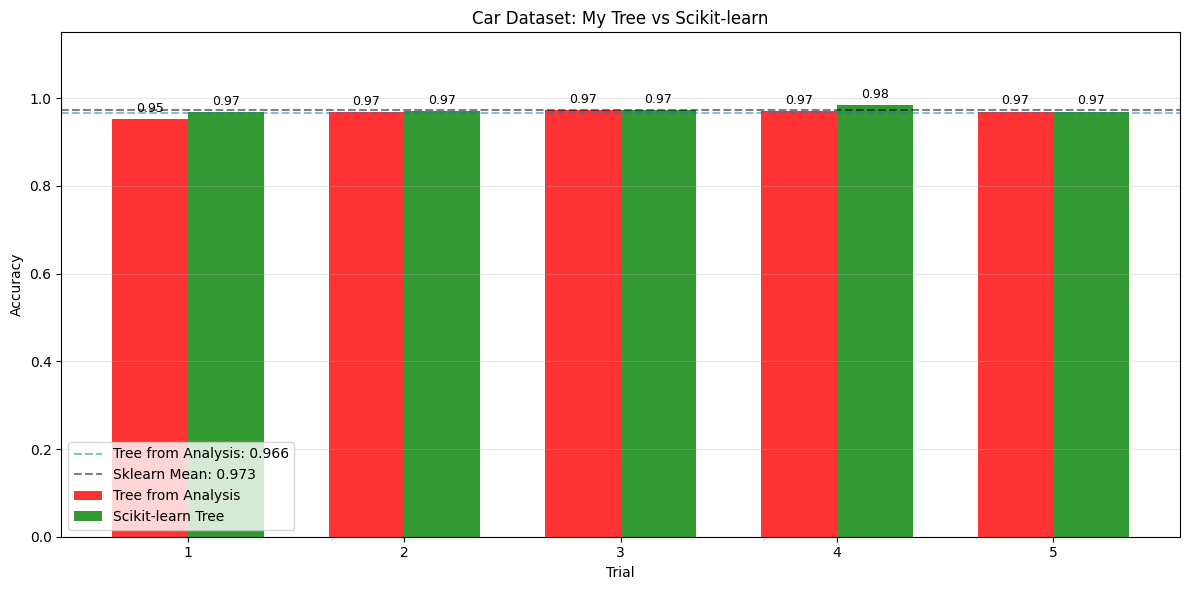

Car Dataset Results:
Tree from Analysis - Mean Accuracy: 0.966 ± 0.008
Sklearn Tree - Mean Accuracy: 0.973 ± 0.006


In [ ]:
# Load car dataset
data_car = pd.read_csv("car.csv")

# Car dataset has all categorical features
# Need to encode them as numbers
from sklearn.preprocessing import LabelEncoder

# Create label encoders for each column
label_encoders = {}
for col in data_car.columns:
    le = LabelEncoder()
    data_car[col] = le.fit_transform(data_car[col])
    label_encoders[col] = le

data_car = data_car.to_numpy()

# All features are nominal for car dataset
feature_types_car = ['n'] * (data_car.shape[1] - 1)

# Run multiple trials
n_trials = 5
my_tree_scores = []
sklearn_scores = []

for trial in range(n_trials):
    # Shuffle and split data
    np.random.shuffle(data_car)

    X = data_car[:, :-1]
    y = data_car[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=trial)

    # Prepare data for my tree
    train_data = np.column_stack([X_train, y_train])

    # Train my tree
    my_tree = grow_tree(train_data, feature_types_car, max_depth=15, min_samples_split=2)

    # Predict with my tree
    y_pred_my = predict_with_tree(my_tree, X_test, feature_types_car)
    my_accuracy = accuracy_score(y_test, y_pred_my)
    my_tree_scores.append(my_accuracy)

    # Train and predict with sklearn
    sklearn_tree = DecisionTreeClassifier(max_depth=15, min_samples_split=2, random_state=trial)
    sklearn_tree.fit(X_train, y_train)
    y_pred_sklearn = sklearn_tree.predict(X_test)
    sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
    sklearn_scores.append(sklearn_accuracy)

# Plot results
plt.figure(figsize=(12, 6))

x_pos = np.arange(n_trials)
width = 0.35

bars_my = plt.bar(
    x_pos - width/2,
    my_tree_scores,
    width,
    label='Tree from Analysis',
    color="red",
    alpha=0.8
)

bars_sklearn = plt.bar(
    x_pos + width/2,
    sklearn_scores,
    width,
    label='Scikit-learn Tree',
    color="green",
    alpha=0.8
)

plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Car Dataset: My Tree vs Scikit-learn')
plt.xticks(x_pos, [f'{i+1}' for i in range(n_trials)])
plt.ylim(0, 1.15)   # 🔹 important: extra headroom
plt.grid(axis='y', alpha=0.3)

# 🔹 ADD VALUES ON BARS (this is the key fix)
plt.bar_label(bars_my, fmt='%.2f', padding=3, fontsize=9)
plt.bar_label(bars_sklearn, fmt='%.2f', padding=3, fontsize=9)

# Mean accuracy lines
plt.axhline(
    y=np.mean(my_tree_scores),
    linestyle='--',
    alpha=0.5,
    label=f'Tree from Analysis: {np.mean(my_tree_scores):.3f}'
)
plt.axhline(
    y=np.mean(sklearn_scores),
    linestyle='--',
    alpha=0.5,
    color="black",
    label=f'Sklearn Mean: {np.mean(sklearn_scores):.3f}'
)

plt.legend()
plt.tight_layout()
plt.show()


print(f"Car Dataset Results:")
print(f"Tree from Analysis - Mean Accuracy: {np.mean(my_tree_scores):.3f} ± {np.std(my_tree_scores):.3f}")
print(f"Sklearn Tree - Mean Accuracy: {np.mean(sklearn_scores):.3f} ± {np.std(sklearn_scores):.3f}")

### 9) Training with normalized data on the wine dataset

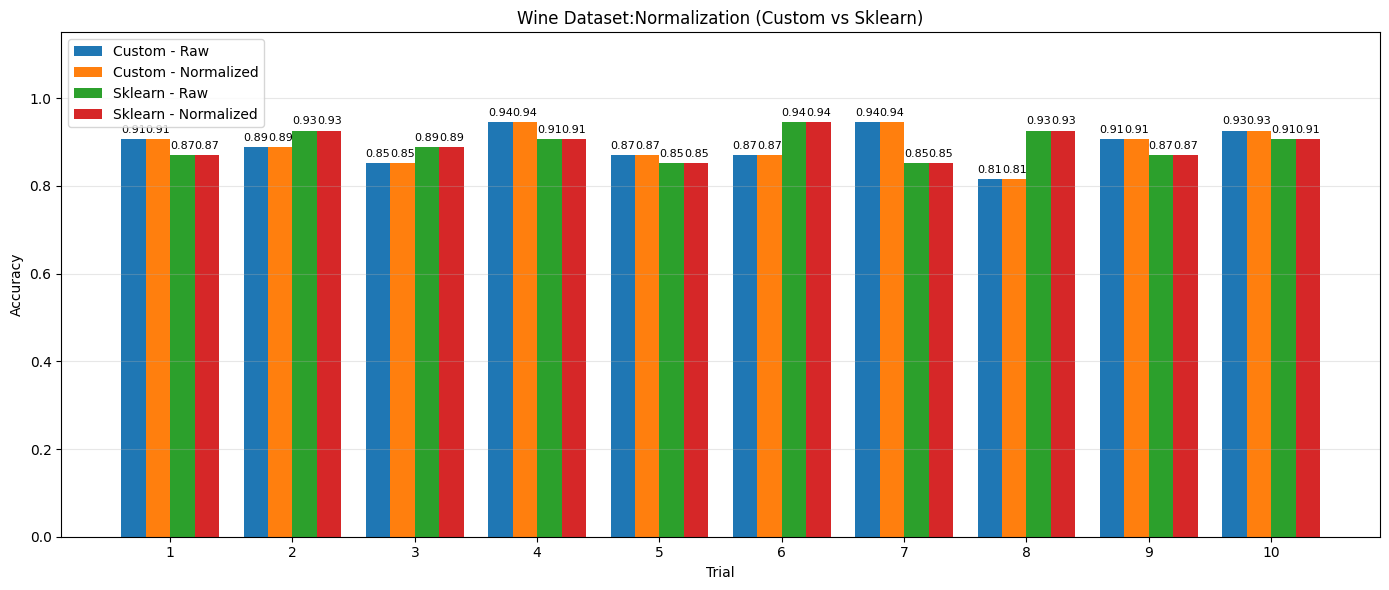

Wine Dataset – Normalization Comparison

Custom Tree (Raw)        : 0.893 ± 0.040
Custom Tree (Normalized) : 0.893 ± 0.040
Sklearn Tree (Raw)       : 0.894 ± 0.031
Sklearn Tree (Normalized): 0.894 ± 0.031


In [ ]:
# -------------------------------------------------
# Load wine dataset
# -------------------------------------------------
data_wine = pd.read_csv("wine.csv")

for col in data_wine.columns:
    data_wine[col] = pd.to_numeric(data_wine[col], errors='coerce')

data_wine = data_wine.dropna()
data_wine = data_wine.to_numpy()

# Separate features and labels
X_wine = data_wine[:, :-1]
y_wine = data_wine[:, -1]

# Normalize features to [0,1]
scaler = preprocessing.MinMaxScaler()
X_wine_normalized = scaler.fit_transform(X_wine)

# Combine normalized data with labels
data_wine_normalized = np.column_stack([X_wine_normalized, y_wine])

feature_types_wine = ['r'] * X_wine.shape[1]

# -------------------------------------------------
# Run trials
# -------------------------------------------------
n_trials = 10

custom_raw_scores = []
custom_norm_scores = []
sklearn_raw_scores = []
sklearn_norm_scores = []

for trial in range(n_trials):

    # ========== CUSTOM TREE : RAW ==========
    np.random.seed(trial)
    np.random.shuffle(data_wine)
    X = data_wine[:, :-1]
    y = data_wine[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=trial
    )

    train_data = np.column_stack([X_train, y_train])
    my_tree_raw = grow_tree(
        train_data,
        feature_types_wine,
        max_depth=10,
        min_samples_split=2
    )

    y_pred_raw = predict_with_tree(my_tree_raw, X_test, feature_types_wine)
    custom_raw_scores.append(accuracy_score(y_test, y_pred_raw))
    # ========== CUSTOM TREE : NORMALIZED ==========
    np.random.seed(trial)
    np.random.shuffle(data_wine_normalized)

    Xn = data_wine_normalized[:, :-1]
    yn = data_wine_normalized[:, -1]

    X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
        Xn, yn, test_size=0.3, random_state=trial
    )

    train_data_norm = np.column_stack([X_train_n, y_train_n])
    my_tree_norm = grow_tree(
        train_data_norm,
        feature_types_wine,
        max_depth=10,
        min_samples_split=2
    )

    y_pred_norm = predict_with_tree(my_tree_norm, X_test_n, feature_types_wine)
    custom_norm_scores.append(accuracy_score(y_test_n, y_pred_norm))

    # ========== SKLEARN TREE : RAW ==========
    sklearn_raw = DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=2,
        random_state=trial
    )
    sklearn_raw.fit(X_train, y_train)
    sklearn_raw_scores.append(
        accuracy_score(y_test, sklearn_raw.predict(X_test))
    )

    # ========== SKLEARN TREE : NORMALIZED ==========
    sklearn_norm = DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=2,
        random_state=trial
    )
    sklearn_norm.fit(X_train_n, y_train_n)
    sklearn_norm_scores.append(
        accuracy_score(y_test_n, sklearn_norm.predict(X_test_n))
    )

# -------------------------------------------------
# Plot results (4 bars per trial)
# -------------------------------------------------
plt.figure(figsize=(14, 6))
x = np.arange(n_trials)
width = 0.2

b1 = plt.bar(x - 1.5*width, custom_raw_scores, width, label='Custom - Raw')
b2 = plt.bar(x - 0.5*width, custom_norm_scores, width, label='Custom - Normalized')
b3 = plt.bar(x + 0.5*width, sklearn_raw_scores, width, label='Sklearn - Raw')
b4 = plt.bar(x + 1.5*width, sklearn_norm_scores, width, label='Sklearn - Normalized')

plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Wine Dataset:Normalization (Custom vs Sklearn)')
plt.xticks(x, [f'{i+1}' for i in range(n_trials)])
plt.ylim(0, 1.15)
plt.grid(axis='y', alpha=0.3)

# Values on bars
for bars in [b1, b2, b3, b4]:
    plt.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Print summary
# -------------------------------------------------
print("Wine Dataset – Normalization Comparison\n")
print(f"Custom Tree (Raw)        : {np.mean(custom_raw_scores):.3f} ± {np.std(custom_raw_scores):.3f}")
print(f"Custom Tree (Normalized) : {np.mean(custom_norm_scores):.3f} ± {np.std(custom_norm_scores):.3f}")
print(f"Sklearn Tree (Raw)       : {np.mean(sklearn_raw_scores):.3f} ± {np.std(sklearn_raw_scores):.3f}")
print(f"Sklearn Tree (Normalized): {np.mean(sklearn_norm_scores):.3f} ± {np.std(sklearn_norm_scores):.3f}")
